【1】数据加载与预处理
原始数据形状: (9357, 15)
列名: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
清洗后剩余有效样本数: 827
标准化后数据维度: (827, 13)
 CO分箱失败 ('Categorical' object has no attribute 'values')，改用KMeans生成伪标签


  File "d:\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\Anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Anaconda3\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pi


【2】网格搜索寻优（为每种方法寻找最优参数）

 搜索 PCA 最优参数...
   {} → 轮廓系数: 0.3890, 耗时: 0.13s
最优: {}, 轮廓系数: 0.3890

 搜索 MDA 最优参数...
   {'n_neighbors': 5} → 轮廓系数: 0.4894, 耗时: 0.11s
   {'n_neighbors': 10} → 轮廓系数: 0.5152, 耗时: 0.09s
   {'n_neighbors': 15} → 轮廓系数: 0.5285, 耗时: 0.12s
最优: {'n_neighbors': 15}, 轮廓系数: 0.5285

 搜索 KPCA 最优参数...
   {'kernel': 'rbf', 'gamma': 0.01} → 轮廓系数: 0.3942, 耗时: 0.04s
   {'kernel': 'rbf', 'gamma': 0.05} → 轮廓系数: 0.5239, 耗时: 0.03s
   {'kernel': 'rbf', 'gamma': 0.1} → 轮廓系数: 0.4642, 耗时: 0.03s
   {'kernel': 'rbf', 'gamma': 0.5} → 轮廓系数: 0.0283, 耗时: 0.03s
   {'kernel': 'rbf', 'gamma': 1.0} → 轮廓系数: -0.1343, 耗时: 0.04s
最优: {'kernel': 'rbf', 'gamma': 0.05}, 轮廓系数: 0.5239

 搜索 ISOMAP 最优参数...
   {'n_neighbors': 8} → 轮廓系数: 0.3748, 耗时: 0.27s
   {'n_neighbors': 12} → 轮廓系数: 0.3721, 耗时: 0.36s
   {'n_neighbors': 15} → 轮廓系数: 0.3779, 耗时: 0.34s
   {'n_neighbors': 20} → 轮廓系数: 0.3809, 耗时: 0.44s
   {'n_neighbors': 30} → 轮廓系数: 0.3824, 耗时: 0.66s
最优: {'n_neighbors': 30}, 轮廓系数: 0.3824

 搜索 t-SNE 最优参数...
   {'pe

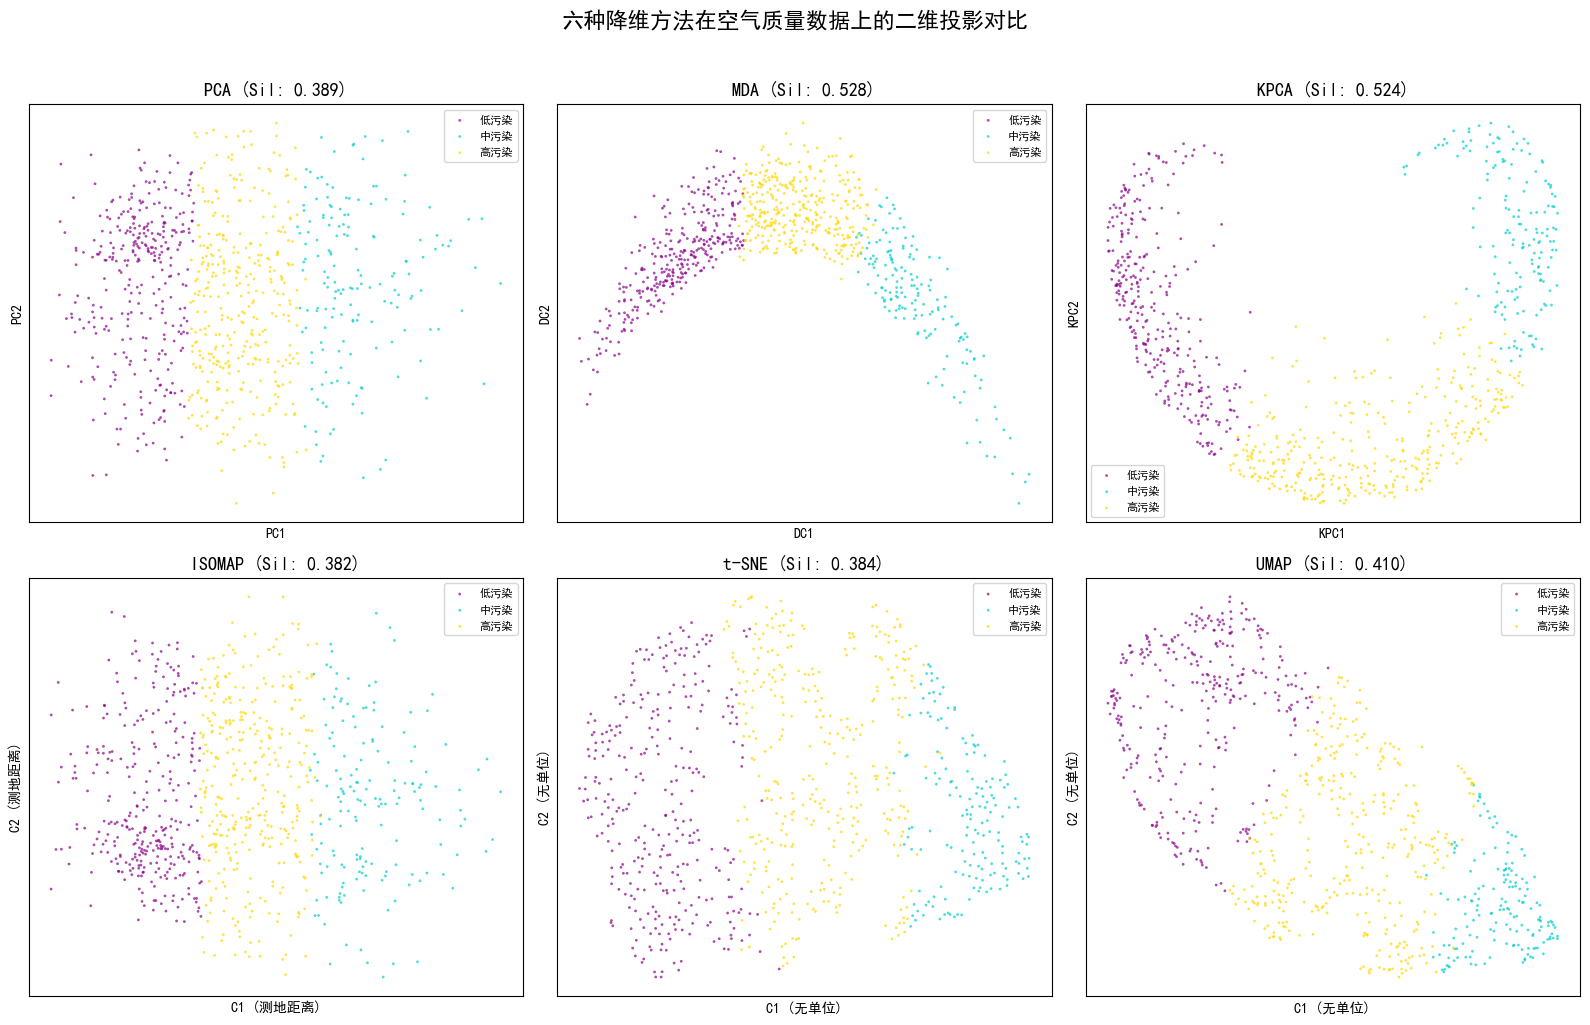

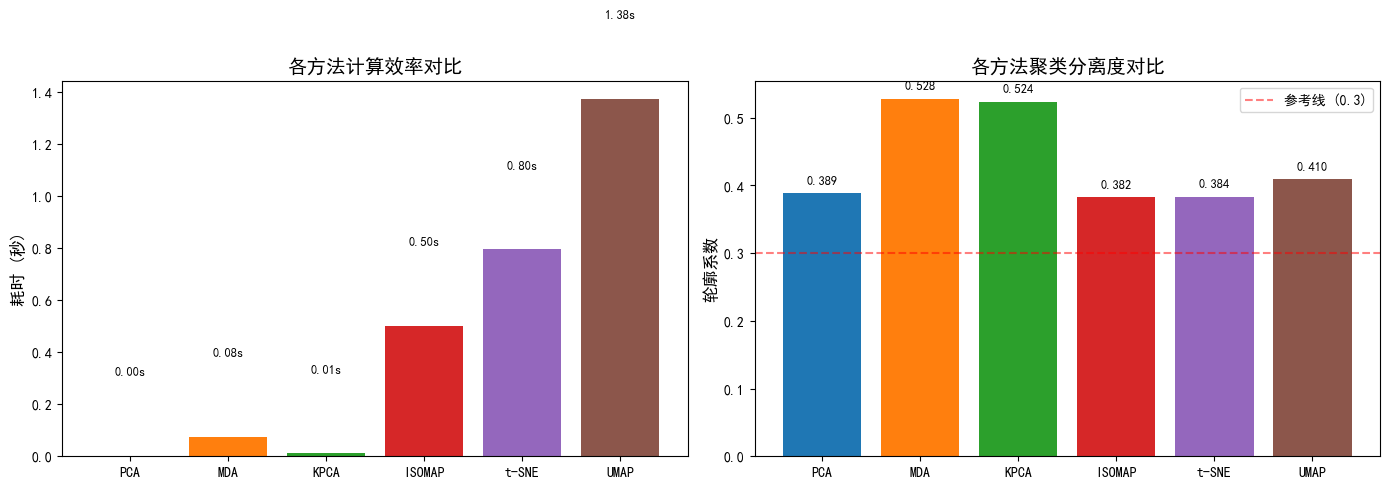


生成 t-SNE 困惑度敏感性分析...


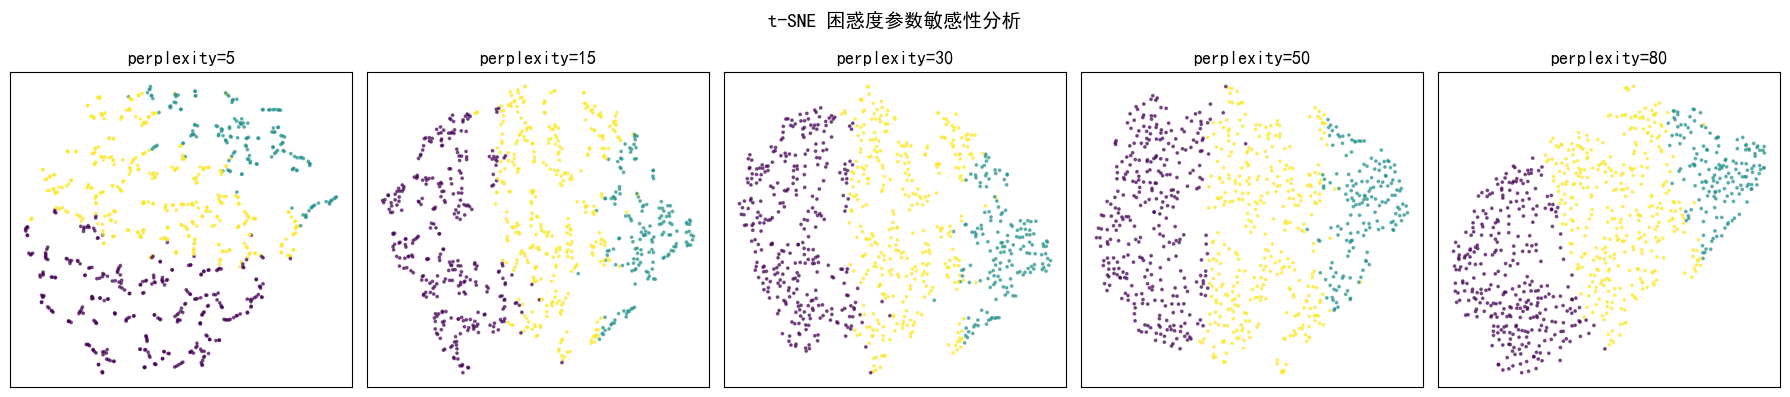


生成 UMAP n_neighbors 敏感性分析...


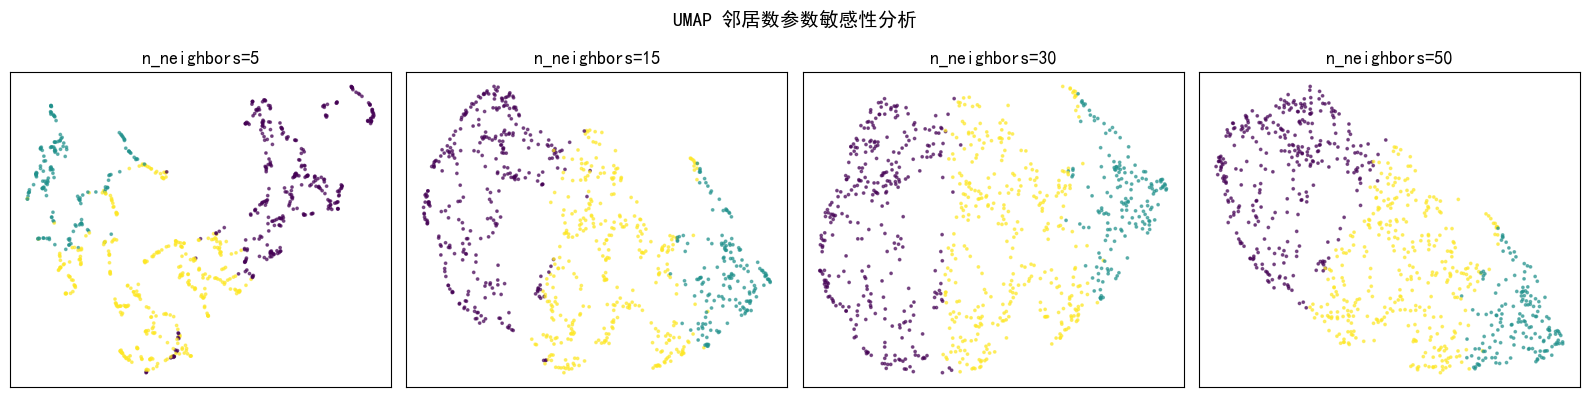


生成特征相关性热力图...


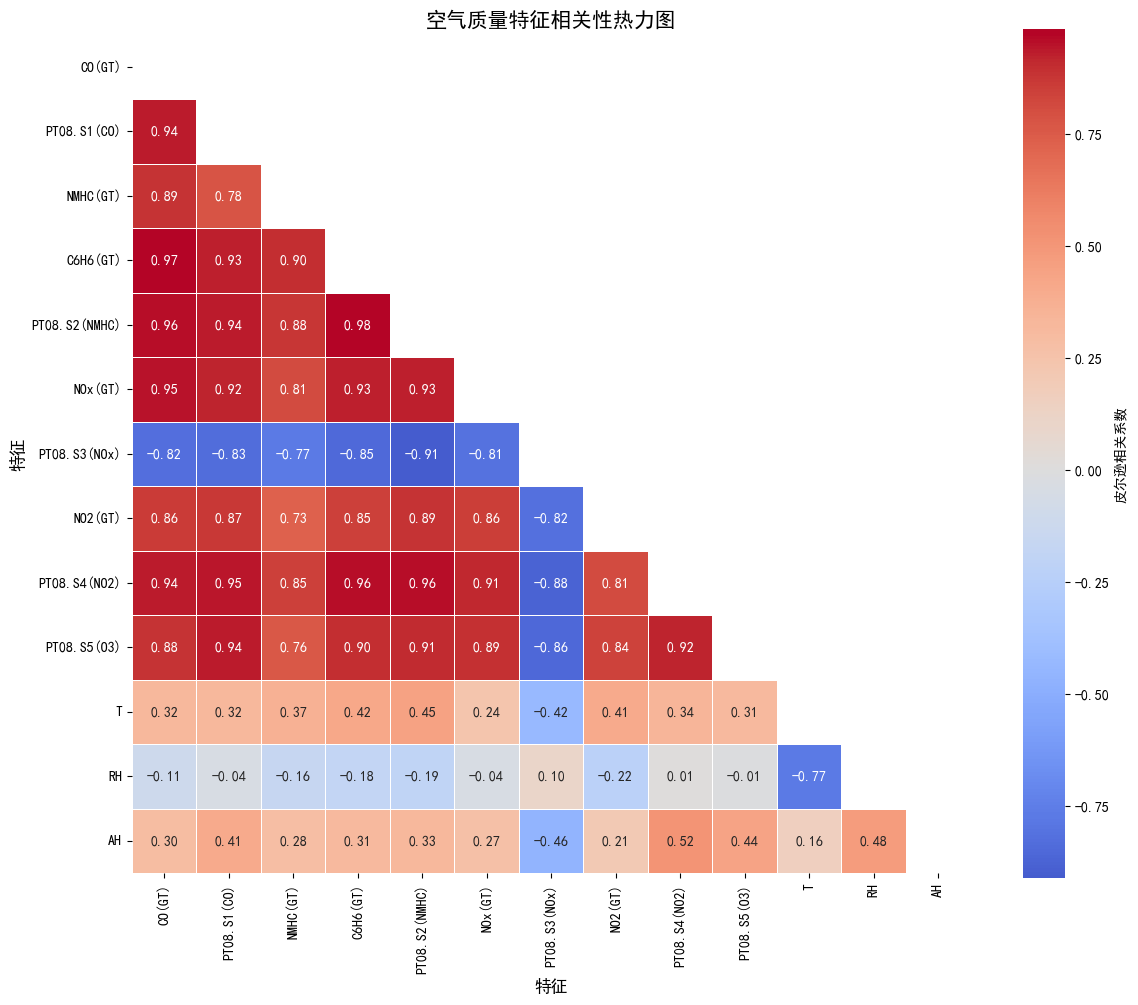


生成CO浓度分布图...


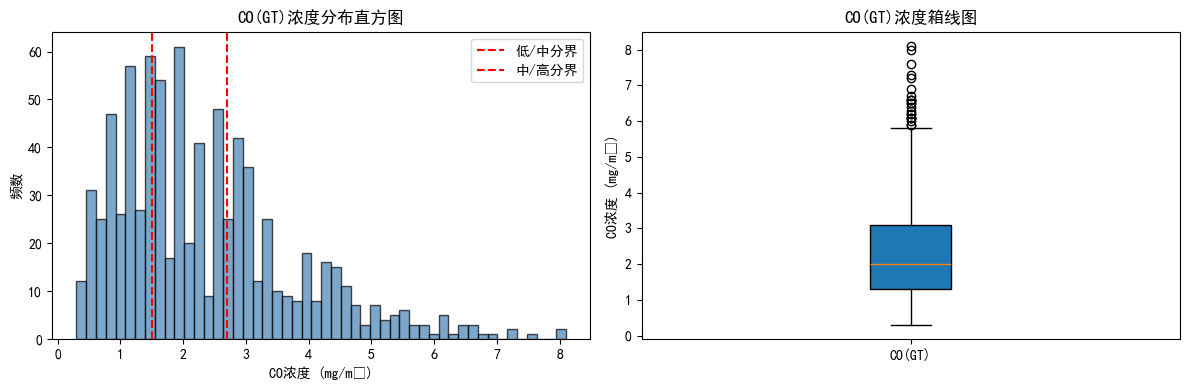



汇总表数据：
方法           轮廓系数        
------------------------------
PCA          0.3890
MDA          0.5285
KPCA         0.5239
ISOMAP       0.3824
t-SNE        0.3837
UMAP         0.4096


In [1]:
"""
高维数据降维对比实验 —— UCI Air Quality 数据集
包含: PCA, MDA, KPCA, ISOMAP, t-SNE, UMAP
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ==================== 0. 全局设置 ====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ==================== 1. 数据加载与预处理 ====================
print("="*70)
print("【1】数据加载与预处理")
print("="*70)

data = pd.read_excel(r"D:\Desktop\各种文件\材料\air+quality\AirQualityUCI.xlsx")
print(f"原始数据形状: {data.shape}")
print(f"列名: {data.columns.tolist()}")

# 1.1 缺失值处理
data.replace(-200.0, np.nan, inplace=True)

# 1.2 删除日期时间列
X_raw = data.drop(columns=['Date', 'Time'])

# 1.3 删除含缺失值的行
X_clean = X_raw.dropna()
print(f"清洗后剩余有效样本数: {X_clean.shape[0]}")

# 1.4 提取特征并标准化
X = X_clean.values.astype(np.float64)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"标准化后数据维度: {X_scaled.shape}")

# 1.5 保留干净DataFrame供后续使用
df = X_clean.copy()

# 1.6 生成伪标签（基于CO(GT)三分位）
try:
    co_values = df['CO(GT)'].values
    y_labels = pd.qcut(co_values, q=3, labels=[0, 1, 2], duplicates='drop').values
    y_labels = y_labels.astype(int)  # 确保为整数类型
    print(f" 生成三分类标签，各类别样本数: {np.bincount(y_labels)}")
except Exception as e:
    print(f" CO分箱失败 ({e})，改用KMeans生成伪标签")
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    y_labels = kmeans.fit_predict(X_scaled)

# ==================== 2. 定义MDA类 ====================
from sklearn.neighbors import kneighbors_graph

class ManifoldDiscriminantAnalysis:
    """
    流形判别分析 (Manifold Discriminant Analysis)
    结合Fisher判别准则与流形正则化
    """
    def __init__(self, n_components=2, n_neighbors=5):
        self.n_components = n_components
        self.n_neighbors = n_neighbors
        self.W = None
        
    def fit_transform(self, X, y):
        n_samples = X.shape[0]
        classes = np.unique(y)
        
        # 类内连接图
        W_within = np.zeros((n_samples, n_samples))
        for c in classes:
            idx = np.where(y == c)[0]
            if len(idx) > 1:
                k = min(self.n_neighbors, len(idx) - 1)
                knn = kneighbors_graph(X[idx], k, mode='connectivity', include_self=False)
                W_within[np.ix_(idx, idx)] = knn.toarray()
        
        # 类间连接图（全连接）
        W_between = np.zeros((n_samples, n_samples))
        for i in range(len(classes)):
            for j in range(i+1, len(classes)):
                idx_i = np.where(y == classes[i])[0]
                idx_j = np.where(y == classes[j])[0]
                for ii in idx_i:
                    for jj in idx_j:
                        W_between[ii, jj] = 1.0
                        W_between[jj, ii] = 1.0
        
        # 计算流形散度矩阵
        D_within = np.diag(np.sum(W_within, axis=1))
        S_W = X.T @ (D_within - W_within) @ X
        
        D_between = np.diag(np.sum(W_between, axis=1))
        S_B = X.T @ (D_between - W_between) @ X
        
        # 正则化防止奇异
        S_W += 1e-6 * np.eye(S_W.shape[0])
        
        # 求解广义特征值问题 S_B w = lambda S_W w
        eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W) @ S_B)
        idx = np.argsort(np.real(eigvals))[::-1]
        self.W = np.real(eigvecs[:, idx[:self.n_components]])
        return X @ self.W

# ==================== 3. 网格搜索寻优 ====================
print("\n"+"="*70)
print("【2】网格搜索寻优（为每种方法寻找最优参数）")
print("="*70)

from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, TSNE
from sklearn.metrics import silhouette_score
import umap

# 3.1 定义搜索空间
param_grids = {
    'PCA': [{}],  # PCA无参数
    
    'MDA': [
        {'n_neighbors': 5},
        {'n_neighbors': 10},
        {'n_neighbors': 15}
    ],
    
    'KPCA': [
        {'kernel': 'rbf', 'gamma': 0.01},
        {'kernel': 'rbf', 'gamma': 0.05},
        {'kernel': 'rbf', 'gamma': 0.1},
        {'kernel': 'rbf', 'gamma': 0.5},
        {'kernel': 'rbf', 'gamma': 1.0}
    ],
    
    'ISOMAP': [
        {'n_neighbors': 8},
        {'n_neighbors': 12},
        {'n_neighbors': 15},
        {'n_neighbors': 20},
        {'n_neighbors': 30}
    ],
    
    't-SNE': [
        {'perplexity': 20, 'learning_rate': 100},
        {'perplexity': 30, 'learning_rate': 200},
        {'perplexity': 30, 'learning_rate': 500},
        {'perplexity': 40, 'learning_rate': 200},
        {'perplexity': 50, 'learning_rate': 200}
    ],
    
    'UMAP': [
        {'n_neighbors': 8, 'min_dist': 0.1},
        {'n_neighbors': 15, 'min_dist': 0.1},
        {'n_neighbors': 15, 'min_dist': 0.01},
        {'n_neighbors': 30, 'min_dist': 0.1},
        {'n_neighbors': 50, 'min_dist': 0.1}
    ]
}

# 3.2 构建方法对象（使用默认参数作为备选）
def build_model(name, params):
    if name == 'PCA':
        return PCA(n_components=2, random_state=42)
    elif name == 'MDA':
        return ManifoldDiscriminantAnalysis(n_components=2, **params)
    elif name == 'KPCA':
        return KernelPCA(n_components=2, random_state=42, **params)
    elif name == 'ISOMAP':
        return Isomap(n_components=2, **params)
    elif name == 't-SNE':
        return TSNE(n_components=2, random_state=42, n_iter=800, **params)
    elif name == 'UMAP':
        return umap.UMAP(n_components=2, random_state=42, **params)

# 3.3 执行搜索
best_results = {}
best_embeddings = {}
best_params = {}
search_times = {}

for name in param_grids.keys():
    print(f"\n 搜索 {name} 最优参数...")
    best_score = -1
    best_X = None
    best_p = None
    
    for params in param_grids[name]:
        try:
            model = build_model(name, params)
            start = time.time()
            
            if name == 'MDA':
                X_emb = model.fit_transform(X_scaled, y_labels)
            else:
                X_emb = model.fit_transform(X_scaled)
            
            elapsed = time.time() - start
            sil = silhouette_score(X_emb, y_labels)
            
            if sil > best_score:
                best_score = sil
                best_X = X_emb
                best_p = params
                
            print(f"   {params} → 轮廓系数: {sil:.4f}, 耗时: {elapsed:.2f}s")
            
        except Exception as e:
            print(f"   {params} → 失败: {str(e)[:40]}")
            continue
    
    best_results[name] = {'silhouette': best_score}
    best_embeddings[name] = best_X
    best_params[name] = best_p
    print(f"最优: {best_p}, 轮廓系数: {best_score:.4f}")

# ==================== 4. 用最优参数重新运行====================
print("\n"+"="*70)
print("最终实验、使用最优参数")

final_results = {}
final_embeddings = {}

for name, params in best_params.items():
    print(f"\n运行 {name} (最优参数: {params})...", end=' ', flush=True)
    start = time.time()
    try:
        model = build_model(name, params)
        if name == 'MDA':
            X_emb = model.fit_transform(X_scaled, y_labels)
        else:
            X_emb = model.fit_transform(X_scaled)
        
        elapsed = time.time() - start
        sil = silhouette_score(X_emb, y_labels)
        
        final_results[name] = {
            'time': elapsed,
            'silhouette': sil,
            'params': str(params)
        }
        final_embeddings[name] = X_emb
        print(f"完成! 耗时: {elapsed:.2f}s, 轮廓系数: {sil:.4f}")
    except Exception as e:
        print(f"失败! {e}")
        final_results[name] = {'time': np.nan, 'silhouette': np.nan, 'params': str(params)}
        final_embeddings[name] = None

# ==================== 5. 输出汇总表 ====================
print("\n"+"="*70)
print("【4】定量评估汇总表（可直接复制到论文第四章）")
print("="*70)
print(f"{'方法':<12} {'最优参数':<28} {'耗时(秒)':<12} {'轮廓系数':<12}")
print("-"*70)
for name, res in final_results.items():
    p = res['params'][:26] if len(res['params']) > 26 else res['params']
    t = f"{res['time']:.2f}" if not np.isnan(res['time']) else "N/A"
    s = f"{res['silhouette']:.4f}" if not np.isnan(res['silhouette']) else "N/A"
    print(f"{name:<12} {p:<28} {t:<12} {s:<12}")

# ==================== 6. 可视化 ====================
print("\n"+"="*70)

# 6.1 六合一对比散点图
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['#8B008B', '#00CED1', '#FFD700']  # 深紫、深青、金色
class_labels = ['低污染', '中污染', '高污染']

# 坐标轴标签映射
axis_labels = {
    'PCA': ('PC1', 'PC2'),
    'KPCA': ('KPC1', 'KPC2'),
    'MDA': ('DC1', 'DC2'),
    'ISOMAP': ('C1 (测地距离)', 'C2 (测地距离)'),
    't-SNE': ('C1 (无单位)', 'C2 (无单位)'),
    'UMAP': ('C1 (无单位)', 'C2 (无单位)')
}

for idx, name in enumerate(final_embeddings.keys()):
    ax = axes[idx]
    X_emb = final_embeddings[name]
    
    if X_emb is not None:
        # 按类别绘制
        for label_id in [0, 1, 2]:
            mask = (y_labels == label_id)
            ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                      c=colors[label_id], label=class_labels[label_id],
                      s=4, alpha=0.7, edgecolors='none')
        
        # 添加轮廓系数到标题
        sil = final_results[name]['silhouette']
        ax.set_title(f'{name} (Sil: {sil:.3f})', fontsize=13, fontweight='bold')
        
        # 专业坐标轴标签
        xlabel, ylabel = axis_labels.get(name, ('C1', 'C2'))
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        
        ax.legend(loc='best', fontsize=8, framealpha=0.8)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.text(0.5, 0.5, f'{name}\n运行失败', ha='center', va='center')
        ax.set_title(name)

# 隐藏多余子图
for j in range(idx+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('六种降维方法在空气质量数据上的二维投影对比', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# 6.2 计算效率柱状图
names = list(final_results.keys())
times = [final_results[n]['time'] if not np.isnan(final_results[n]['time']) else 0 for n in names]
sil_scores = [final_results[n]['silhouette'] if not np.isnan(final_results[n]['silhouette']) else 0 for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：耗时
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = axes[0].bar(names, times, color=colors_bar)
axes[0].set_ylabel('耗时 (秒)', fontsize=12)
axes[0].set_title('各方法计算效率对比', fontsize=14)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{t:.2f}s', ha='center', va='bottom', fontsize=9)

# 右图：轮廓系数
bars2 = axes[1].bar(names, sil_scores, color=colors_bar)
axes[1].set_ylabel('轮廓系数', fontsize=12)
axes[1].set_title('各方法聚类分离度对比', fontsize=14)
axes[1].axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='参考线 (0.3)')
axes[1].legend()
for bar, s in zip(bars2, sil_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{s:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
# 6.3 t-SNE 困惑度敏感性
print("\n生成 t-SNE 困惑度敏感性分析...")
perplexities = [5, 15, 30, 50, 80]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 4))
for idx, perp in enumerate(perplexities):
    try:
        tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200,
                    random_state=42, n_iter=500)
        X_emb = tsne.fit_transform(X_scaled)
        axes[idx].scatter(X_emb[:, 0], X_emb[:, 1], c=y_labels,
                         cmap='viridis', s=3, alpha=0.6)
        axes[idx].set_title(f'perplexity={perp}', fontsize=13)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'失败', ha='center', va='center')
        axes[idx].set_title(f'perplexity={perp}')
plt.suptitle('t-SNE 困惑度参数敏感性分析', fontsize=14)
plt.tight_layout()
plt.show()

# 6.4 UMAP n_neighbors 敏感性
print("\n生成 UMAP n_neighbors 敏感性分析...")
n_neighbors_list = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(n_neighbors_list), figsize=(16, 4))
for idx, n_nbr in enumerate(n_neighbors_list):
    try:
        umap_model = umap.UMAP(n_components=2, n_neighbors=n_nbr,
                               min_dist=0.1, random_state=42)
        X_emb = umap_model.fit_transform(X_scaled)
        axes[idx].scatter(X_emb[:, 0], X_emb[:, 1], c=y_labels,
                         cmap='viridis', s=3, alpha=0.6)
        axes[idx].set_title(f'n_neighbors={n_nbr}', fontsize=13)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'失败', ha='center', va='center')
        axes[idx].set_title(f'n_neighbors={n_nbr}')
plt.suptitle('UMAP 邻居数参数敏感性分析', fontsize=14)
plt.tight_layout()
plt.show()

# 6.5 相关性热力图
print("\n生成特征相关性热力图...")
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': '皮尔逊相关系数'})
plt.title('空气质量特征相关性热力图', fontsize=15)
plt.xlabel('特征', fontsize=12)
plt.ylabel('特征', fontsize=12)
plt.tight_layout()
plt.show()


# 6.6 CO浓度分布图
print("\n生成CO浓度分布图...")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['CO(GT)'].values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['CO(GT)'].quantile(1/3), color='red', linestyle='--', label='低/中分界')
axes[0].axvline(df['CO(GT)'].quantile(2/3), color='red', linestyle='--', label='中/高分界')
axes[0].set_xlabel('CO浓度 (mg/m³)')
axes[0].set_ylabel('频数')
axes[0].set_title('CO(GT)浓度分布直方图')
axes[0].legend()

axes[1].boxplot([df['CO(GT)'].values], vert=True, patch_artist=True)
axes[1].set_ylabel('CO浓度 (mg/m³)')
axes[1].set_title('CO(GT)浓度箱线图')
axes[1].set_xticklabels(['CO(GT)'])
plt.tight_layout()
plt.show()


# ==================== 7. 最终总结 ====================
print("\n"+"="*70)
print("\n汇总表数据：")
print(f"{'方法':<12} {'轮廓系数':<12}")
print("-"*30)
for name in final_results.keys():
    print(f"{name:<12} {final_results[name]['silhouette']:.4f}")
